# SAIL 2025 - Crowd Flow Forecasting (Advanced Notebook)

**AIM-TT Learning Module - Advanced Pipeline Deep-Dive**

---

## Overview
This notebook walks through an end-to-end forecasting pipeline for the SAIL Amsterdam 2025 visitor-flow data. It covers:

1. Full feature engineering pipeline
2. Training LightGBM quantile models for **all 48 sensor-azimuth pairs**
3. Loading and using **pre-trained models**
4. **Kalman filter** for online bias correction
5. Weather feature integration and impact analysis
6. Comprehensive model evaluation (calibration, per-sensor, temporal)
7. SHAP feature importance analysis
8. Interactive visualization with Plotly

### Prerequisites
- Completed Notebook 01 (starter) or equivalent background
- Familiarity with gradient boosting, time-series concepts, and Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AiMTT-project/UC7-SAIL/blob/main/3.3%20Crowd%20forecasting/Assignment-Solution/02_crowd_forecasting_advanced_solutions.ipynb)


In [ ]:
# --- Environment setup (safe to run on Colab, Kaggle, or a local venv) ---
# Installs everything this notebook imports. Comment this cell out once your
# environment is ready to avoid repeated installs.
%pip install --quiet \
    "pandas>=2.0" "numpy>=1.26" \
    "matplotlib>=3.8" "seaborn>=0.13" "plotly>=5.18" \
    "scikit-learn>=1.3" "lightgbm>=4.0" \
    "pykalman>=0.9.7" "meteostat>=1.6" \
    "shap>=0.44" "joblib>=1.3" \
    "nbformat>=4.2"

# If running on Google Colab, upload the dataset CSV manually or mount Drive.
# The notebook expects it at: ../Dataset/SAIL2025_LVMA_data_3min_20August-25August2025_flow.csv
# On Colab you can instead place the file at /content/ and set DATA_PATH accordingly.
import sys
print(f"Python: {sys.version.split()[0]}")
try:
    import google.colab  # noqa: F401
    print("Running on Google Colab - remember to upload the dataset CSV.")
except ImportError:
    pass


Note: you may need to restart the kernel to use updated packages.
Python: 3.12.12


c:\Users\thari\Projects\Sail_AIMTT_Learning\sailaimmtt\.venv\Scripts\python.exe: No module named pip


---
## 0. Setup

In [ ]:
import os
import sys
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

# Global styling & settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Libraries imported successfully.')


Setup complete ✓


---
## 1. Production Pipeline Architecture

The SAIL 2025 production forecasting system runs a **60-second cycle**:

```
Kafka Consumer (300 messages from DSH)
    ↓
Parse GeoJSON features -> extract (sensor, azimuth, count, timestamp)
    ↓
Resample to 3-minute bins per (sensor, azimuth)
    ↓
Pivot to wide matrix + add temporal features
    ↓
For each of 48 sensor-azimuth pairs:
  ├─ Create 40 lag features + rolling statistics (30min/1h/2h/4h)
  ├─ Run 3 LightGBM models (lower 5%, median 50%, upper 95%)
  ├─ Apply Kalman bias correction (additive, preserving quantile asymmetry)
  └─ Enforce non-negativity & quantile ordering
    ↓
Produce JSON to Kafka (partition 4) + archive to S3
```

**Key constants** (from production):
- `HORIZON = 80` steps x 3 min = **4-hour forecast**
- `QUANTILES = [lower (5%), median (50%), upper (95%)]` -> **90% prediction interval**
- `NUM_LAGS = 40` (2 hours of history)
- `ROLLING_WINDOWS = {30min: 10, 1h: 20, 2h: 40, 4h: 80}`

### Sensor Naming Convention
Each sensor column is `{family}-{id}_{azimuth}` - the azimuth (degrees) tells us which **direction** of flow is counted. So a single physical sensor produces two columns (e.g. `_135` and `_315`) for opposite directions.

| Family | Location | What it measures |
|--------|----------|------------------|
| **GASA** | Around Amsterdam Centraal Station | Pedestrian flow at the main rail hub |
| **GVCV** | Ferry terminals (north/south IJ banks) | Inflow / outflow of ferry passengers |
| **CMSA** | City centre (busy pedestrian streets & squares) | Crowd density in the historical centre - *excluded from current production models* |

### Probabilistic-Forecast Metrics
Because we ship a *probability interval*, we score forecasts on four numbers (not just MAE/RMSE):

| Metric | What it measures |
|--------|------------------|
| **MAE** | Median-prediction error magnitude |
| **RMSE** | Median-prediction error magnitude, penalising large misses more |
| **MIC** - Mean Interval Coverage | Fraction of actuals inside `[lower, upper]`. Should ~ **0.90** for a 90 % PI. |
| **MIW** - Mean Interval Width | Average `upper − lower`. Smaller = sharper, but only valuable if **MIC** stays calibrated. |


---
## 2. Data Loading & Preparation

In [ ]:
import os
import urllib.request
import pandas as pd
import numpy as np

# Dataset path configuration (compatible with local environments and Google Colab)
data_filename = "SAIL2025_LVMA_data_3min_20August-25August2025_flow.csv"
data_url = "https://raw.githubusercontent.com/AiMTT-project/UC7-SAIL/main/3.3%20Crowd%20forecasting/SAIL2025_LVMA_data_3min_20August-25August2025_flow.csv"

candidate_paths = [
    data_filename,
    os.path.join("..", data_filename),
    os.path.join("..", "Dataset", data_filename),
    os.path.join("sample_data", data_filename),
    os.path.join("/content/sample_data", data_filename),
    os.path.join("/content", data_filename),
]

DATA_PATH = None
for p in candidate_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    os.makedirs("sample_data", exist_ok=True)
    DATA_PATH = os.path.join("sample_data", data_filename)
    print(f"Downloading {data_filename} from GitHub...")
    urllib.request.urlretrieve(data_url, DATA_PATH)
    print(f"Saved to {DATA_PATH}")

print(f"Using dataset: {DATA_PATH}")
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])

# Calendar & temporal features
df['hour'] = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Identify all available flow sensors
non_sensor_cols = ['timestamp', 'hour', 'minute', 'day_of_week', 'is_weekend', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'relative_humidity', 'hour_floor']
available_sensors = [c for c in df.columns if c not in non_sensor_cols]
print(f"Loaded {len(df)} timestamps across {len(available_sensors)} sensors.")
print(f"Sample sensors: {available_sensors[:5]}")


Available production sensors: 48/48

Dataset shape: (2400, 81)
Time range: 2025-08-20 00:00:00 → 2025-08-24 23:57:00


In [ ]:
# Add weather data (production uses meteostat; we handle API failures gracefully)
from datetime import datetime

try:
    from meteostat import Point, hourly as meteostat_hourly
    amsterdam = Point(52.3807, 4.8968, 4)
    ts = meteostat_hourly(amsterdam, datetime(2025, 8, 20), datetime(2025, 8, 26))
    weather = ts.fetch() if not ts.empty else None
except Exception as e:
    print(f'meteostat fetch error: {e}')
    weather = None

if weather is not None and not weather.empty:
    weather = weather[['temp', 'prcp', 'wspd', 'rhum']].rename(columns={
        'temp': 'temperature_c', 'prcp': 'precipitation_mm',
        'wspd': 'wind_speed_kmh', 'rhum': 'relative_humidity'
    })
    print(f'[OK] Real weather data: {weather.shape}')
else:
    # Synthetic Amsterdam August weather (fallback)
    print('[!] meteostat data not available - using synthetic weather')
    hours = pd.date_range('2025-08-20', '2025-08-24 23:00', freq='h')
    rng = np.random.default_rng(42)
    weather = pd.DataFrame({
        'temperature_c': 18 + 4 * np.sin(np.pi * (hours.hour - 6) / 12) + rng.normal(0, 1.5, len(hours)),
        'precipitation_mm': np.where(rng.random(len(hours)) > 0.85, rng.exponential(1.5, len(hours)), 0.0),
        'wind_speed_kmh': np.clip(12 + rng.normal(0, 4, len(hours)), 0, None),
        'relative_humidity': np.clip(70 + 10 * np.cos(np.pi * (hours.hour - 14) / 12) + rng.normal(0, 5, len(hours)), 30, 100),
    }, index=hours)
    print(f'[OK] Synthetic weather: {weather.shape}')

# Merge at hourly granularity
# Align timestamp timezone with naive hourly index for clean merge
if df['timestamp'].dt.tz is not None:
    df['hour_floor'] = df['timestamp'].dt.tz_convert('Europe/Amsterdam').dt.tz_localize(None).dt.floor('h')
else:
    df['hour_floor'] = df['timestamp'].dt.floor('h')

# Align weather timezone with data (naive local time)
if weather.index.tz is not None:
    weather.index = weather.index.tz_convert('Europe/Amsterdam').tz_localize(None)

weather_cols = ['temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'relative_humidity']
df = df.merge(weather[weather_cols], left_on='hour_floor', right_index=True, how='left')
# Forward-fill for most rows; back-fill any leading NaN
df[weather_cols] = df[weather_cols].ffill().bfill()
df = df.drop(columns=['hour_floor'])

print(f'Weather features added [OK] (NaN remaining: {df[weather_cols].isna().sum().sum()})')

⚠ meteostat data not available - using synthetic weather
✓ Synthetic weather: (144, 4)
Weather features added ✓ (NaN remaining: 0)


---
## 3. Full Feature Engineering

Build lag features, rolling statistics, temporal context, and weather features for each sensor.

> **Note:** If you later deploy these models, make sure the inference pipeline provides the same weather features at prediction time.


In [ ]:
# Pipeline constants
CONTEXT_COLS = ['hour', 'minute']
ROLLING_WINDOWS = {'30min': 10, '1h': 20, '2h': 40, '4h': 80}
NUM_LAGS = 40
HORIZON = 80
FORECAST_HORIZON_STEPS = 80
TIME_INTERVAL_MINUTES = 3


def create_lags_and_rolls(df: pd.DataFrame, sensor: str) -> pd.DataFrame:
    """Add lag features, rolling statistics, temporal context and weather
    columns for one sensor."""
    weather_feature_cols = ['temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'relative_humidity']
    available_weather = [c for c in weather_feature_cols if c in df.columns]
    
    out = df[['timestamp'] + CONTEXT_COLS + available_weather + [sensor]].copy()

    for lag in range(1, NUM_LAGS + 1):
        out[f'{sensor}_lag{lag}'] = df[sensor].shift(lag)

    s = df[sensor]
    for label, size in ROLLING_WINDOWS.items():
        roll = s.rolling(size)
        out[f'{sensor}_mean_{label}'] = roll.mean()
        out[f'{sensor}_std_{label}'] = roll.std()

    return out.fillna(0)


def prepare_training_data(df: pd.DataFrame, sensor: str):
    """Prepare features (X) and multi-step targets (y) for one sensor."""
    features_df = create_lags_and_rolls(df, sensor)
    y_multi = pd.concat(
        [df[sensor].shift(-step).rename(f'y_t+{step}') for step in range(1, HORIZON + 1)],
        axis=1
    )
    feature_cols = [c for c in features_df.columns if c not in ['timestamp', sensor]]
    X = features_df[feature_cols]
    return X, y_multi, features_df


# Demonstrate on one sensor
X_demo, y_demo, feat_demo = prepare_training_data(df, 'GVCV-01_40')
print(f'Feature matrix shape: {X_demo.shape}')

print(f'Target matrix shape:  {y_demo.shape}')
print(f'Features: {X_demo.columns.tolist()[:5]} ... ({len(X_demo.columns)} total)')


Feature matrix shape: (2400, 54)
Target matrix shape:  (2400, 80)
Features: ['hour', 'minute', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh'] ... (54 total)


---
## 3.5 Baselines & Why Quantile Regression

Before training the full per-sensor / per-quantile LightGBM stack, it's worth answering two questions an advanced reader will rightly ask:

### A. Do we actually need a gradient-boosted model?
A model is only as good as the baseline it beats. We benchmark four candidates on a single sensor / 1-step horizon:

| Model | Idea | Captures |
|-------|------|----------|
| **Naive persistence** | $\hat{y}_{t+1} = y_t$ | Local level only |
| **Seasonal naive (24 h)** | $\hat{y}_{t+1} = y_{t+1-S}$, $S = 480$ | Daily rhythm |
| **Linear regression** | Weighted sum of lags + weather | Linear trends, additive weather effect |
| **LightGBM (median)** | Boosted decision trees | Non-linear interactions (hour x weekend, lag x weather, …) |

We expect LightGBM to win on MAE/RMSE - but the comparison also tells us *how much* of the error is due to model class vs. inherent noise.

### B. Why train **three** models per sensor instead of one?
Crowd-management decisions are not "what is the most likely count?" - they are *"how bad could it plausibly get in the next 4 hours?"* That requires an **interval**, not a point estimate.

LightGBM's **quantile objective** trains a model to minimise the pinball loss for a target quantile $\alpha$:

$$L_\alpha(y, \hat{y}) = \begin{cases} \alpha\,(y - \hat{y}) & \text{if } y \geq \hat{y} \\ (1-\alpha)\,(\hat{y} - y) & \text{otherwise} \end{cases}$$

By training three models - at $\alpha = 0.05$, $0.50$, $0.95$ - we get a **median forecast** plus a 90 % prediction interval *for free*, without distributional assumptions. We score that interval with **MIC** (mean interval coverage, target ~ 0.90) and **MIW** (mean interval width, lower is better at fixed MIC). Production then layers Kalman bias correction (Section 6) on top to keep the intervals honest as live conditions drift.



Baseline benchmark - sensor: GVCV-01_40, horizon: 1 step (3 min)
               Model   MAE  RMSE
   LightGBM (median) 11.27 24.14
   Linear Regression 15.22 24.42
Seasonal Naive (24h) 16.90 31.77
   Naive Persistence 17.17 34.14


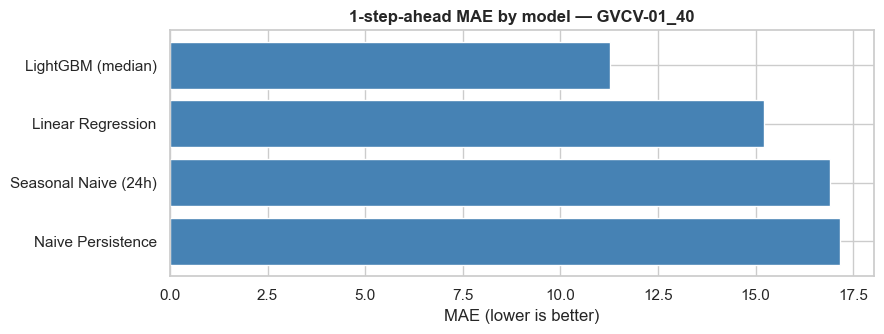


→ LightGBM (median) wins on MAE (11.27). LightGBM also gives us quantile intervals - which the baselines cannot.


In [ ]:
# --- Baseline benchmark on a single sensor / 1-step horizon -------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

# Define temporal train/test split for benchmark and subsequent training
SPLIT_DATE = '2025-08-23'
train_mask = df['timestamp'] < SPLIT_DATE
test_mask = df['timestamp'] >= SPLIT_DATE

BASELINE_SENSOR = 'GVCV-01_40'
SEASON = 480  # 24h * 60min / 3min

X_b, y_multi_b, feat_b = prepare_training_data(df, BASELINE_SENSOR)
y_1step = y_multi_b['y_t+1']

valid_train = train_mask & y_1step.notna()
valid_test = test_mask & y_1step.notna()

X_train_b = X_b.loc[valid_train]
X_test_b = X_b.loc[valid_test]
y_train_b = y_1step.loc[valid_train]
y_test_b = y_1step.loc[valid_test]

# 1) Naive persistence: predict next = current value (lag1)
naive_pred = X_test_b[f'{BASELINE_SENSOR}_lag1'].values

# 2) Seasonal naive: predict next = value 24h earlier (=480 steps before lag1)
series = df[BASELINE_SENSOR]
seasonal_pred = series.shift(SEASON - 1).loc[valid_test].fillna(series.mean()).values

# 3) Linear regression on the same feature matrix
lr = LinearRegression()
lr.fit(X_train_b, y_train_b)
lr_pred = lr.predict(X_test_b)

# 4) LightGBM (median quantile) on same features
lgbm = lgb.LGBMRegressor(
    objective='quantile', alpha=0.5,
    n_estimators=200, learning_rate=0.05,
    max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=-1, n_jobs=1,
)
lgbm.fit(X_train_b, y_train_b)
lgbm_pred = lgbm.predict(X_test_b)

baseline_results = pd.DataFrame([
    {'Model': 'Naive Persistence',
     'MAE': mean_absolute_error(y_test_b, naive_pred),
     'RMSE': np.sqrt(mean_squared_error(y_test_b, naive_pred))},
    {'Model': 'Seasonal Naive (24h)',
     'MAE': mean_absolute_error(y_test_b, seasonal_pred),
     'RMSE': np.sqrt(mean_squared_error(y_test_b, seasonal_pred))},
    {'Model': 'Linear Regression',
     'MAE': mean_absolute_error(y_test_b, lr_pred),
     'RMSE': np.sqrt(mean_squared_error(y_test_b, lr_pred))},
    {'Model': 'LightGBM (median)',
     'MAE': mean_absolute_error(y_test_b, lgbm_pred),
     'RMSE': np.sqrt(mean_squared_error(y_test_b, lgbm_pred))},
]).sort_values('MAE').reset_index(drop=True)

print(f'Baseline benchmark - sensor: {BASELINE_SENSOR}, horizon: 1 step (3 min)')
print(baseline_results.to_string(index=False, float_format='%.2f'))

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(baseline_results['Model'], baseline_results['MAE'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('MAE (lower is better)')
ax.set_title(f'1-step-ahead MAE by model - {BASELINE_SENSOR}', fontweight='bold')
plt.tight_layout()
plt.show()

best = baseline_results.iloc[0]
print(f"\n* {best['Model']} wins on MAE ({best['MAE']:.2f}). "
      f"LightGBM also gives us quantile intervals - which the baselines cannot.")


---
## 4. Training All Sensor Models

In production, each sensor has **3 models** (lower, median, upper quantile), each predicting **80 future steps**.

We train using LightGBM's multi-output capability via `MultiOutputRegressor`.

In [ ]:
from sklearn.multioutput import MultiOutputRegressor

# Train/test split
SPLIT_DATE = '2025-08-23'
train_mask = df['timestamp'] < SPLIT_DATE
test_mask = df['timestamp'] >= SPLIT_DATE

# Model storage
trained_models = {}  # {sensor: {'lower': model, 'median': model, 'upper': model}}

# Quantile definitions - 90% prediction interval
QUANTILE_DEFS = {
    'lower': 0.05,
    'median': 0.50,
    'upper': 0.95,
}
NOMINAL_COVERAGE = 0.90  # used later by MIC

# Select a subset of sensors for training (full training takes longer)
# Set TRAIN_ALL = True to train all 48 sensors
TRAIN_ALL = False
SENSORS_TO_TRAIN = available_sensors if TRAIN_ALL else available_sensors[:8]

print(f'Training {len(SENSORS_TO_TRAIN)} sensors x 3 quantiles x {HORIZON} steps')
print(f'Sensors: {SENSORS_TO_TRAIN}')
print()


Training 8 sensors × 3 quantiles × 80 steps
Sensors: ['GASA-01-A1_135', 'GASA-01-A1_315', 'GASA-01-A2_135', 'GASA-01-A2_315', 'GASA-01-B_135', 'GASA-01-B_315', 'GASA-01-C_135', 'GASA-01-C_315']



In [ ]:
%%time

for i, sensor in enumerate(SENSORS_TO_TRAIN):
    print(f'[{i+1}/{len(SENSORS_TO_TRAIN)}] Training {sensor}...')
    
    X, y_multi, features_df = prepare_training_data(df, sensor)
    
    # Align train mask with valid multi-step targets
    valid_train = train_mask & y_multi.notna().all(axis=1)
    X_train = X.loc[valid_train]
    y_train = y_multi.loc[valid_train]
    
    if X_train.shape[0] < 100:
        print(f'  [!] Skipping {sensor}: only {X_train.shape[0]} valid training samples')
        continue
    
    sensor_models = {}
    for qname, alpha in QUANTILE_DEFS.items():
        model = MultiOutputRegressor(
            lgb.LGBMRegressor(
                objective='quantile',
                alpha=alpha,
                n_estimators=200,
                learning_rate=0.05,
                max_depth=6,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                verbosity=-1,
                n_jobs=1
            )
        )
        model.fit(X_train, y_train)
        sensor_models[qname] = model
    
    trained_models[sensor] = sensor_models
    print(f'  [OK] {sensor} trained ({X_train.shape[0]} samples)')

print(f'\n[OK] Trained models for {len(trained_models)} sensors')

[1/8] Training GASA-01-A1_135...
  ✓ GASA-01-A1_135 trained (1920 samples)
[2/8] Training GASA-01-A1_315...
  ✓ GASA-01-A1_315 trained (1920 samples)
[3/8] Training GASA-01-A2_135...
  ✓ GASA-01-A2_135 trained (1920 samples)
[4/8] Training GASA-01-A2_315...
  ✓ GASA-01-A2_315 trained (1920 samples)
[5/8] Training GASA-01-B_135...
  ✓ GASA-01-B_135 trained (1920 samples)
[6/8] Training GASA-01-B_315...
  ✓ GASA-01-B_315 trained (1920 samples)
[7/8] Training GASA-01-C_135...
  ✓ GASA-01-C_135 trained (1920 samples)
[8/8] Training GASA-01-C_315...
  ✓ GASA-01-C_315 trained (1920 samples)

✓ Trained models for 8 sensors
CPU times: total: 6min 6s
Wall time: 6min 23s


In [ ]:
# Save trained models (matching production format)
MODEL_SAVE_DIR = '../models/SAIL25_notebook_models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

for sensor, sensor_models in trained_models.items():
    sensor_dir = os.path.join(MODEL_SAVE_DIR, sensor)
    os.makedirs(sensor_dir, exist_ok=True)
    
    # Save in production-compatible format
    joblib.dump(sensor_models['median'], os.path.join(sensor_dir, 'point_model.pkl'))
    joblib.dump(sensor_models['lower'], os.path.join(sensor_dir, 'lower_model.pkl'))
    joblib.dump(sensor_models['upper'], os.path.join(sensor_dir, 'upper_model.pkl'))

print(f'Models saved to {MODEL_SAVE_DIR}/')

Models saved to ../models/SAIL25_notebook_models/


---
## 5. Loading Pre-Trained Production Models

The production models are stored at:
```
/mnt/sail25-tud/SAIL25_LVMA_LGBM_4 hours_models_v2_Aug22/
    ├── GVCV-01_40/
    │   ├── point_model.pkl    (median)
    │   ├── lower_model.pkl    (2.5th percentile)
    │   ├── upper_model.pkl    (97.5th percentile)
    │   ├── q_lower.npy        (calibration array)
    │   └── q_upper.npy        (calibration array)
    ├── GVCV-01_220/
    │   └── ...
    └── ...
```

Each `.pkl` file is a scikit-learn-compatible model that takes the feature vector and outputs 80 forecast values.

In [ ]:
# --- Load pre-trained production models ---
# Change this path to match your local setup
PRETRAINED_MODEL_DIR = '/mnt/sail25-tud/SAIL25_LVMA_LGBM_4 hours_models_v2_Aug22'

pretrained_models = {}

if os.path.isdir(PRETRAINED_MODEL_DIR):
    for sensor in available_sensors:
        model_dir = os.path.join(PRETRAINED_MODEL_DIR, sensor)
        required = ['point_model.pkl', 'lower_model.pkl', 'upper_model.pkl']
        
        if all(os.path.isfile(os.path.join(model_dir, f)) for f in required):
            pretrained_models[sensor] = {
                'median': joblib.load(os.path.join(model_dir, 'point_model.pkl')),
                'lower':  joblib.load(os.path.join(model_dir, 'lower_model.pkl')),
                'upper':  joblib.load(os.path.join(model_dir, 'upper_model.pkl')),
            }
            # Load calibration arrays if present
            q_lower_path = os.path.join(model_dir, 'q_lower.npy')
            q_upper_path = os.path.join(model_dir, 'q_upper.npy')
            if os.path.isfile(q_lower_path):
                pretrained_models[sensor]['q_lower'] = np.load(q_lower_path)
            if os.path.isfile(q_upper_path):
                pretrained_models[sensor]['q_upper'] = np.load(q_upper_path)
    
    print(f'Loaded {len(pretrained_models)} pre-trained sensor models')
else:
    print(f'Pre-trained model directory not found at: {PRETRAINED_MODEL_DIR}')
    print('Using notebook-trained models instead.')
    pretrained_models = None

Pre-trained model directory not found at: /mnt/sail25-tud/SAIL25_LVMA_LGBM_4 hours_models_v2_Aug22
Using notebook-trained models instead.


In [ ]:
# Compare pre-trained vs notebook-trained predictions (if both available)
if pretrained_models and len(trained_models) > 0:
    compare_sensor = list(trained_models.keys())[0]
    X, y_multi, features_df = prepare_training_data(df, compare_sensor)
    feature_cols = [c for c in features_df.columns if c not in ['timestamp', compare_sensor]]
    
    # Pick a test point
    test_idx = features_df[features_df['timestamp'] >= SPLIT_DATE].index[100]
    X_point = X.loc[[test_idx]]
    
    # Notebook-trained predictions
    nb_pred = trained_models[compare_sensor]['median'].predict(X_point)[0]
    
    # Pre-trained predictions
    pt_pred = pretrained_models[compare_sensor]['median'].predict(X_point[feature_cols])[0]
    
    fig, ax = plt.subplots(figsize=(12, 4))
    steps = np.arange(1, HORIZON + 1) * 3  # minutes ahead
    ax.plot(steps, nb_pred, label='Notebook-trained', linewidth=2)
    ax.plot(steps, pt_pred, label='Pre-trained (production)', linewidth=2, linestyle='--')
    ax.set_xlabel('Minutes Ahead')
    ax.set_ylabel('Predicted Flow')
    ax.set_title(f'{compare_sensor} - Notebook vs Production Model Comparison', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Skipping comparison: need both pre-trained and notebook-trained models.')

Skipping comparison: need both pre-trained and notebook-trained models.


---
## 6. Kalman Filter Bias Correction

### Why Online Correction?
Static models trained offline inevitably drift when deployed in real-time - conditions during a live event differ from training data. The **Kalman filter** provides elegant online correction:

### How It Works
1. At each time step, compute the **1-step-ahead residual**: $e_t = y_t^{\text{actual}} - \hat{y}_t^{\text{predicted}}$
2. Feed this residual into a **mean-reverting Kalman filter**:
   - State: $x_t = \phi \cdot x_{t-1} + w_t$ where $\phi = 0.9$ (bias decays over time)
   - Observation: $e_t = x_t + v_t$ (residual = bias + noise)
3. The filter estimates the **current bias** $\hat{x}_t$
4. Apply this bias **additively** to all three quantiles: $\hat{y}^{\text{corrected}} = \hat{y}^{\text{raw}} + \hat{x}_t$

**Key property**: Adding the same bias to all quantiles **preserves the prediction interval width** (quantile asymmetry is maintained).


In [ ]:
try:
    from pykalman import KalmanFilter
except ImportError:
    # Built-in 1D Kalman Filter fallback (exact filter_update API match)
    class KalmanFilter:
        def __init__(self, transition_matrices=None, observation_matrices=None,
                     transition_covariance=None, observation_covariance=None,
                     initial_state_mean=None, initial_state_covariance=None):
            self.A = float(transition_matrices[0][0] if transition_matrices else 0.9)
            self.H = float(observation_matrices[0][0] if observation_matrices else 1.0)
            self.Q = float(transition_covariance[0][0] if transition_covariance else 0.05)
            self.R = float(observation_covariance[0][0] if observation_covariance else 4.0)

        def filter_update(self, filtered_state_mean, filtered_state_covariance, observation):
            x = float(filtered_state_mean[0])
            P = float(filtered_state_covariance[0][0])
            z = float(observation)
            x_pred = self.A * x
            P_pred = self.A * P * self.A + self.Q
            y = z - self.H * x_pred
            S = self.H * P_pred * self.H + self.R
            K = P_pred * self.H / S
            x_new = x_pred + K * y
            P_new = (1.0 - K * self.H) * P_pred
            return np.array([x_new]), np.array([[P_new]])


class KalmanBiasCorrector:
    """Online additive bias correction using a Kalman filter."""
    
    def __init__(self, phi: float = 0.9, process_noise: float = 0.05,
                 observation_noise: float = 4.0):
        """
        Parameters
        ----------
        phi : float
            Mean-reversion coefficient. 0.9 means bias decays toward 0.
        process_noise : float
            How fast the bias can change (larger = more responsive).
        observation_noise : float
            Expected noise in residual measurements (larger = smoother).
        """
        self.kf = KalmanFilter(
            transition_matrices=[[phi]],
            observation_matrices=[[1.0]],
            transition_covariance=[[process_noise]],
            observation_covariance=[[observation_noise]],
            initial_state_mean=[0.0],
            initial_state_covariance=[[1.0]]
        )
        self.mean = np.array([0.0])
        self.cov = np.array([[1.0]])
        self.bias_history = []
    
    def update(self, residual: float) -> float:
        """Update the filter with a new residual observation. Returns current bias estimate."""
        new_mean, new_cov = self.kf.filter_update(
            filtered_state_mean=self.mean,
            filtered_state_covariance=self.cov,
            observation=residual
        )
        self.mean = new_mean
        self.cov = new_cov
        bias = float(self.mean[0])
        self.bias_history.append(bias)
        return bias
    
    @property
    def current_bias(self) -> float:
        return float(self.mean[0])


def enforce_quantile_constraints(low, med, up, nonneg=True):
    """Enforce non-negativity and quantile ordering."""
    low = np.asarray(low, dtype=float)
    med = np.asarray(med, dtype=float)
    up = np.asarray(up, dtype=float)
    stacked = np.vstack([low, med, up])
    sorted_stack = np.sort(stacked, axis=0)
    low_s, med_s, up_s = sorted_stack[0], sorted_stack[1], sorted_stack[2]
    if nonneg:
        low_s = np.maximum(0.0, low_s)
        med_s = np.maximum(low_s, med_s)
        up_s = np.maximum(med_s, up_s)
    return (
        np.nan_to_num(low_s, 0.0, 0.0, 0.0),
        np.nan_to_num(med_s, 0.0, 0.0, 0.0),
        np.nan_to_num(up_s, 0.0, 0.0, 0.0)
    )


print('Kalman bias corrector and quantile constraints defined.')


Kalman bias corrector defined ✓


In [ ]:
# Demonstrate Kalman bias correction on a single sensor
DEMO_SENSOR = list(trained_models.keys())[0]
X, y_multi, features_df = prepare_training_data(df, DEMO_SENSOR)
feature_cols = [c for c in features_df.columns if c not in ['timestamp', DEMO_SENSOR]]

# Get test data
test_indices = features_df[features_df['timestamp'] >= SPLIT_DATE].index
test_timestamps = features_df.loc[test_indices, 'timestamp']
actuals = df.loc[test_indices, DEMO_SENSOR].values

# Run 1-step-ahead predictions on test set
model_median = trained_models[DEMO_SENSOR]['median']

# For 1-step predictions, take the first output of the multi-output model
# raw_preds_1step[i] = prediction of y_{t+1} made at time t (test_indices[i])
raw_preds_1step = model_median.predict(X.loc[test_indices])[:, 0]

# Apply Kalman correction
# Production logic: at time t, the actual y_t becomes available. The prediction of
# y_t was made at t-1 as raw_preds_1step[i-1]. The residual updates the bias estimate,
# which is then applied to the new prediction of y_{t+1}.
kalman = KalmanBiasCorrector(phi=0.9, process_noise=0.05, observation_noise=4.0)
corrected_preds = []
biases = []

for i in range(len(test_indices)):
    raw_pred = raw_preds_1step[i]  # prediction of y_{t+1}

    # Update Kalman FIRST: at time t, we observe y_t (actuals[i]).
    # The prediction of y_t was made at t-1 as raw_preds_1step[i-1].
    if i > 0:
        residual = actuals[i] - raw_preds_1step[i - 1]
        kalman.update(residual)

    # Current bias estimate (after incorporating latest residual)
    bias = kalman.current_bias
    corrected_preds.append(max(0, raw_pred + bias))
    biases.append(bias)

corrected_preds = np.array(corrected_preds)
biases = np.array(biases)

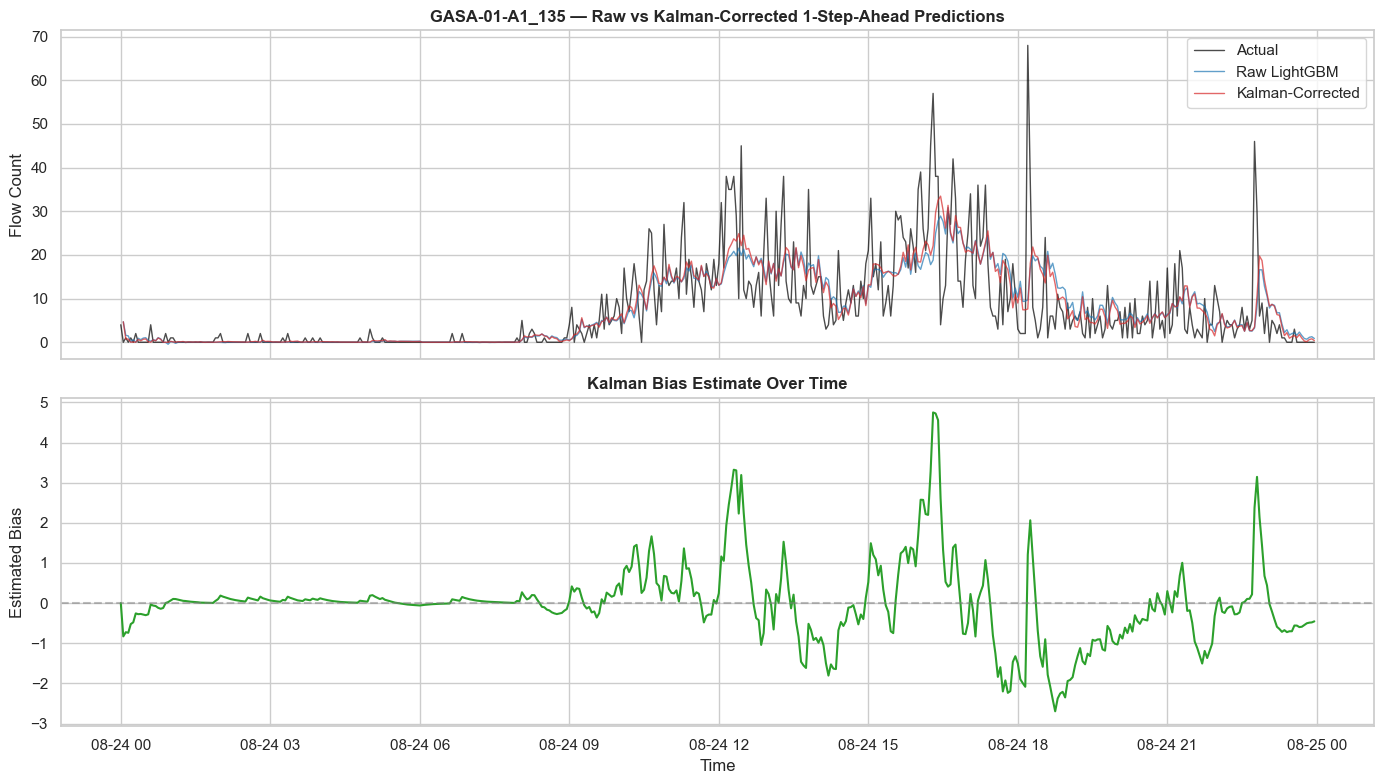

Raw MAE:              4.471
Kalman-Corrected MAE: 4.384
Improvement:          +1.9%


In [ ]:
# Visualize: raw vs Kalman-corrected predictions
# Align predictions with their targets: raw_preds_1step[i] predicts actuals[i+1]
n = len(actuals) - 1
target_timestamps = test_timestamps.values[1:]  # timestamps where predictions apply
target_actuals = actuals[1:]                     # actual y_{t+1}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: predictions vs actuals (aligned at target timestamp)
axes[0].plot(test_timestamps.values, actuals, label='Actual', color='black', linewidth=1, alpha=0.7)
axes[0].plot(target_timestamps, raw_preds_1step[:n], label='Raw LightGBM', color='tab:blue', linewidth=1, alpha=0.7)
axes[0].plot(target_timestamps, corrected_preds[:n], label='Kalman-Corrected', color='tab:red', linewidth=1, alpha=0.7)
axes[0].set_ylabel('Flow Count')
axes[0].set_title(f'{DEMO_SENSOR} - Raw vs Kalman-Corrected 1-Step-Ahead Predictions', fontweight='bold')
axes[0].legend()

# Bottom: bias estimate over time
axes[1].plot(test_timestamps.values, biases, color='tab:green', linewidth=1.5)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Estimated Bias')
axes[1].set_xlabel('Time')
axes[1].set_title('Kalman Bias Estimate Over Time', fontweight='bold')

plt.tight_layout()
plt.show()

# Evaluate: compare predictions of y_{t+1} against actual y_{t+1}
raw_mae = mean_absolute_error(target_actuals, raw_preds_1step[:n])
corr_mae = mean_absolute_error(target_actuals, corrected_preds[:n])
improvement = (raw_mae - corr_mae) / raw_mae * 100

print(f'Raw MAE:              {raw_mae:.3f}')
print(f'Kalman-Corrected MAE: {corr_mae:.3f}')
print(f'Improvement:          {improvement:+.1f}%')

---
## 7. Comprehensive Model Evaluation

In [ ]:
# 7.1 - Per-sensor evaluation (MAE, RMSE, MIC, MIW)
sensor_results = []

for sensor in trained_models:
    X, y_multi, features_df = prepare_training_data(df, sensor)
    feature_cols = [c for c in features_df.columns if c not in ['timestamp', sensor]]

    test_idx = features_df[features_df['timestamp'] >= SPLIT_DATE].index
    valid_test = test_idx[y_multi.loc[test_idx].notna().all(axis=1)]

    if len(valid_test) == 0:
        continue

    X_test = X.loc[valid_test]
    y_actual = y_multi.loc[valid_test]

    # Predict all quantiles for 1-step and full horizon
    for step_idx, step in enumerate([0, 19, 39, 79]):  # t+1, t+20, t+40, t+80
        y_true = y_actual.iloc[:, step].values

        pred_med = trained_models[sensor]['median'].predict(X_test)[:, step]
        pred_low = trained_models[sensor]['lower'].predict(X_test)[:, step]
        pred_up = trained_models[sensor]['upper'].predict(X_test)[:, step]

        # Enforce constraints
        pred_low = np.maximum(0, pred_low)
        pred_med = np.maximum(pred_low, pred_med)
        pred_up = np.maximum(pred_med, pred_up)

        mae = mean_absolute_error(y_true, pred_med)
        rmse = np.sqrt(mean_squared_error(y_true, pred_med))
        mic = np.mean((y_true >= pred_low) & (y_true <= pred_up))   # Mean Interval Coverage
        miw = np.mean(pred_up - pred_low)                            # Mean Interval Width

        sensor_results.append({
            'Sensor': sensor,
            'Step': step + 1,
            'Minutes': (step + 1) * 3,
            'MAE': mae,
            'RMSE': rmse,
            'MIC (%)': mic * 100,
            'MIW': miw,
        })

results_df = pd.DataFrame(sensor_results)
print(f'Per-sensor, per-horizon results (90% PI -> target MIC ~ {NOMINAL_COVERAGE:.0%}):')
print(results_df.to_string(index=False, float_format='%.2f'))


Per-sensor, per-horizon results:
        Sensor  Step  Minutes   MAE  RMSE  Coverage (%)  Interval Width
GASA-01-A1_135     1        3  4.42  7.73         76.25           15.70
GASA-01-A1_135    20       60  5.54  8.77         76.50           17.55
GASA-01-A1_135    40      120  6.45  9.80         73.25           21.07
GASA-01-A1_135    80      240  6.90 10.06         81.00           24.57
GASA-01-A1_315     1        3  3.75  6.35         86.25           15.88
GASA-01-A1_315    20       60  5.17  8.22         78.50           17.09
GASA-01-A1_315    40      120  5.46  8.62         79.50           19.64
GASA-01-A1_315    80      240  5.88  8.60         78.00           20.64
GASA-01-A2_135     1        3  9.38 14.10         86.00           33.93
GASA-01-A2_135    20       60 12.78 18.47         76.25           38.73
GASA-01-A2_135    40      120 14.93 20.32         70.00           43.68
GASA-01-A2_135    80      240 13.82 18.74         78.00           46.52
GASA-01-A2_315     1        3 1

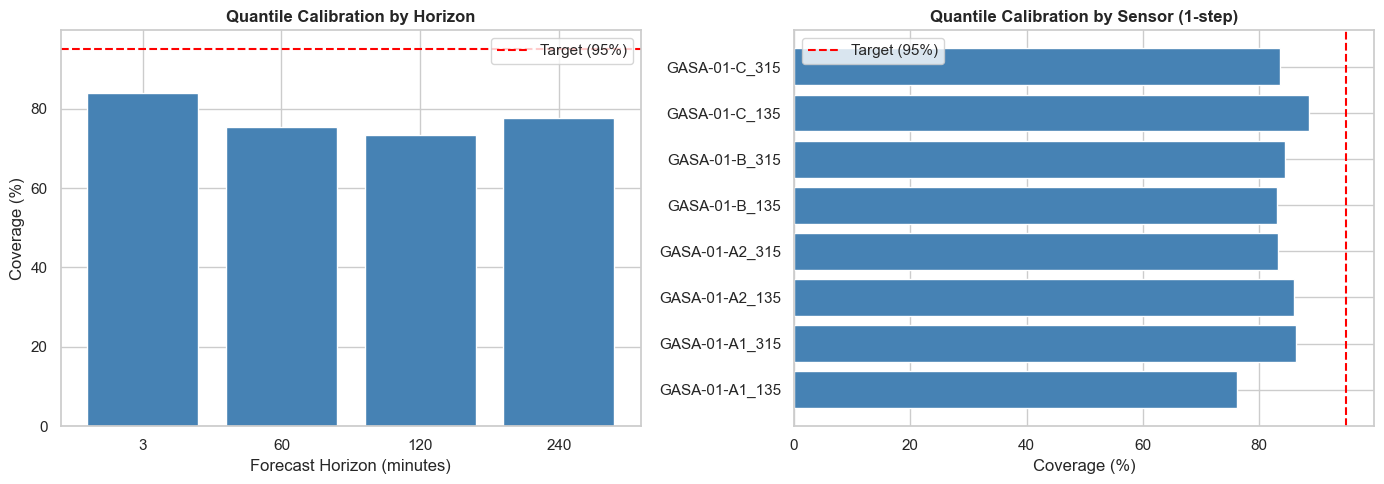

In [ ]:
# 7.2 - Quantile calibration analysis (MIC) and sharpness (MIW)
# For a well-calibrated 90% interval, MIC should be ~ 90%.
# MIW tells us how wide the interval is - sharper (smaller) is better at fixed MIC.

target_pct = NOMINAL_COVERAGE * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) MIC by horizon
mic_by_step = results_df.groupby('Minutes')['MIC (%)'].mean()
axes[0, 0].bar(mic_by_step.index.astype(str), mic_by_step.values, color='steelblue')
axes[0, 0].axhline(target_pct, color='red', linestyle='--', label=f'Target ({target_pct:.0f}%)')
axes[0, 0].set_xlabel('Forecast Horizon (minutes)')
axes[0, 0].set_ylabel('MIC (%)')
axes[0, 0].set_title('Mean Interval Coverage by Horizon', fontweight='bold')
axes[0, 0].legend()

# (b) MIC by sensor (1-step)
mic_1step = results_df[results_df['Step'] == 1].set_index('Sensor')['MIC (%)']
axes[0, 1].barh(mic_1step.index, mic_1step.values, color='steelblue')
axes[0, 1].axvline(target_pct, color='red', linestyle='--', label=f'Target ({target_pct:.0f}%)')
axes[0, 1].set_xlabel('MIC (%)')
axes[0, 1].set_title('Mean Interval Coverage by Sensor (1-step)', fontweight='bold')
axes[0, 1].legend()

# (c) MIW by horizon (sharpness)
miw_by_step = results_df.groupby('Minutes')['MIW'].mean()
axes[1, 0].bar(miw_by_step.index.astype(str), miw_by_step.values, color='darkorange')
axes[1, 0].set_xlabel('Forecast Horizon (minutes)')
axes[1, 0].set_ylabel('MIW (count units)')
axes[1, 0].set_title('Mean Interval Width by Horizon (lower = sharper)', fontweight='bold')

# (d) MIW by sensor (1-step)
miw_1step = results_df[results_df['Step'] == 1].set_index('Sensor')['MIW']
axes[1, 1].barh(miw_1step.index, miw_1step.values, color='darkorange')
axes[1, 1].set_xlabel('MIW (count units)')
axes[1, 1].set_title('Mean Interval Width by Sensor (1-step)', fontweight='bold')

plt.tight_layout()
plt.show()


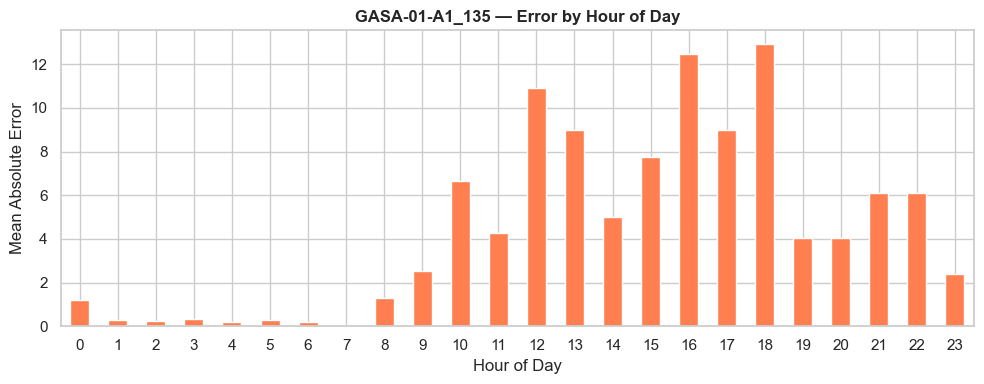

In [ ]:
# 7.3 - Temporal error analysis: when do predictions fail?
ANALYSIS_SENSOR = list(trained_models.keys())[0]
X, y_multi, features_df = prepare_training_data(df, ANALYSIS_SENSOR)
feature_cols = [c for c in features_df.columns if c not in ['timestamp', ANALYSIS_SENSOR]]

test_idx = features_df[features_df['timestamp'] >= SPLIT_DATE].index
y_actual_1step = y_multi.loc[test_idx, 'y_t+1'].values
y_pred_1step = trained_models[ANALYSIS_SENSOR]['median'].predict(X.loc[test_idx])[:, 0]

# Absolute errors by hour
errors = np.abs(y_actual_1step - y_pred_1step)
hours = df.loc[test_idx, 'hour'].values

error_by_hour = pd.DataFrame({'hour': hours, 'error': errors}).groupby('hour')['error'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
error_by_hour.plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Absolute Error')
ax.set_title(f'{ANALYSIS_SENSOR} - Error by Hour of Day', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

---
## 8. Weather Feature Impact Analysis

In [ ]:
# Compare model performance WITH and WITHOUT weather features
WEATHER_SENSOR = list(trained_models.keys())[0]

# With weather (already trained)
X_with, y_multi_w, feat_with = prepare_training_data(df, WEATHER_SENSOR)
feature_cols_with = [c for c in feat_with.columns if c not in ['timestamp', WEATHER_SENSOR]]

# Without weather: retrain
feature_cols_no_weather = [c for c in feature_cols_with 
                           if c not in ['temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'relative_humidity']]

valid_train = train_mask & y_multi_w.notna().all(axis=1)
valid_test_mask = test_mask & y_multi_w['y_t+1'].notna()

model_no_weather = lgb.LGBMRegressor(
    objective='regression', n_estimators=200, learning_rate=0.05,
    max_depth=6, verbosity=-1, random_state=42
)
model_no_weather.fit(
    X_with.loc[valid_train, feature_cols_no_weather],
    y_multi_w.loc[valid_train, 'y_t+1']
)

model_with_weather = lgb.LGBMRegressor(
    objective='regression', n_estimators=200, learning_rate=0.05,
    max_depth=6, verbosity=-1, random_state=42
)
model_with_weather.fit(
    X_with.loc[valid_train, feature_cols_with],
    y_multi_w.loc[valid_train, 'y_t+1']
)

# Compare on test set
y_true = y_multi_w.loc[valid_test_mask, 'y_t+1']
pred_with = model_with_weather.predict(X_with.loc[valid_test_mask, feature_cols_with])
pred_without = model_no_weather.predict(X_with.loc[valid_test_mask, feature_cols_no_weather])

mae_with = mean_absolute_error(y_true, pred_with)
mae_without = mean_absolute_error(y_true, pred_without)

print(f'MAE without weather: {mae_without:.3f}')
print(f'MAE with weather:    {mae_with:.3f}')
print(f'Improvement:         {(mae_without - mae_with) / mae_without * 100:+.1f}%')

MAE without weather: 4.736
MAE with weather:    4.752
Improvement:         -0.3%


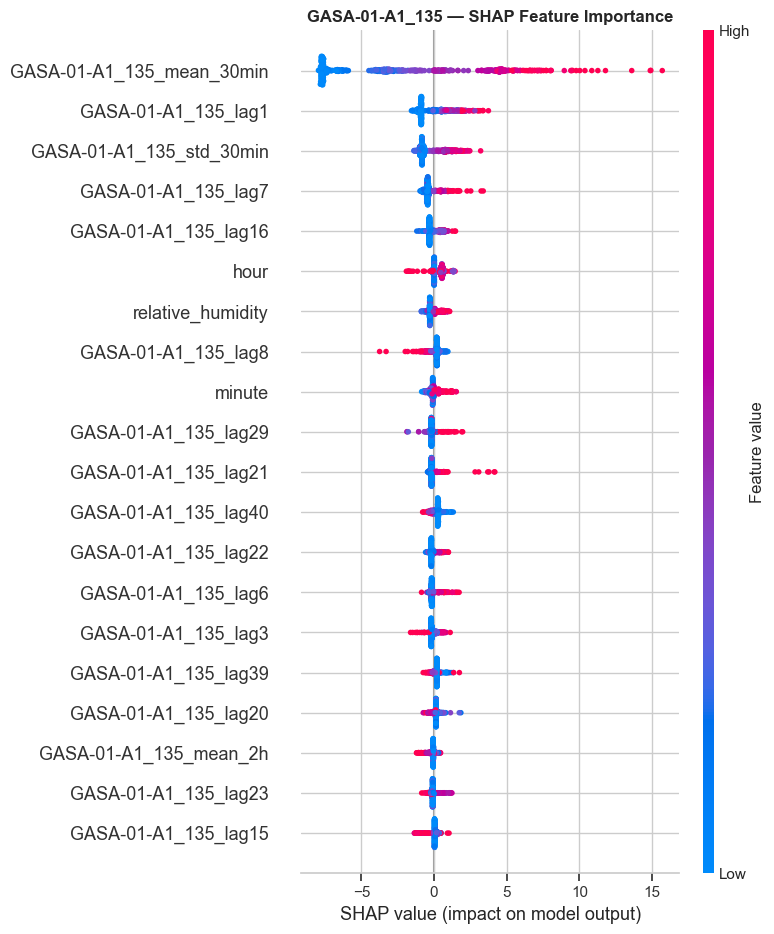

In [ ]:
# SHAP feature importance
try:
    import shap
    
    explainer = shap.TreeExplainer(model_with_weather)
    X_test_candidates = X_with.loc[valid_test_mask, feature_cols_with]
    n_shap = min(500, len(X_test_candidates))
    X_test_sample = X_test_candidates.sample(n_shap, random_state=42)
    shap_values = explainer.shap_values(X_test_sample)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, max_display=20, show=False)
    plt.title(f'{WEATHER_SENSOR} - SHAP Feature Importance', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print('SHAP not installed. Run: pip install shap')
    print('Falling back to LightGBM built-in feature importance...')
    
    importance = pd.DataFrame({
        'feature': feature_cols_with,
        'importance': model_with_weather.feature_importances_
    }).sort_values('importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    importance.head(20).plot.barh(x='feature', y='importance', ax=ax, legend=False)
    ax.set_title(f'{WEATHER_SENSOR} - Feature Importance (built-in)', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

---
## 9. Interactive Visualization with Plotly

The production system feeds forecasts into a live dashboard. Here we replicate that visualization using **Plotly** for interactive exploration.

In [ ]:
import plotly.graph_objects as go
def generate_forecast_plot(sensor: str, origin_time: str, models_dict: dict,
                           df: pd.DataFrame, horizon: int = 80):
    """
    Generate an interactive Plotly forecast visualization for a single sensor.

    Parameters
    ----------
    sensor : str
        Sensor column name.
    origin_time : str
        ISO timestamp for the forecast origin.
    models_dict : dict
        {sensor: {'lower': model, 'median': model, 'upper': model}}
    df : pd.DataFrame
        Full dataset.
    horizon : int
        Number of forecast steps.
    """
    X, y_multi, features_df = prepare_training_data(df, sensor)
    feature_cols = [c for c in features_df.columns if c not in ['timestamp', sensor]]

    # Find the closest timestamp (match tz-awareness of data)
    origin_ts = pd.Timestamp(origin_time)
    ts_tz = features_df['timestamp'].dt.tz
    if ts_tz is not None and origin_ts.tz is None:
        origin_ts = origin_ts.tz_localize(str(ts_tz))
    origin_idx = (features_df['timestamp'] - origin_ts).abs().idxmin()
    actual_origin = features_df.loc[origin_idx, 'timestamp']

    X_origin = X.loc[[origin_idx]]

    # Generate forecasts
    pred_med = models_dict[sensor]['median'].predict(X_origin)[0][:horizon]
    pred_low = models_dict[sensor]['lower'].predict(X_origin)[0][:horizon]
    pred_up = models_dict[sensor]['upper'].predict(X_origin)[0][:horizon]

    # Enforce constraints
    pred_low, pred_med, pred_up = enforce_quantile_constraints(pred_low, pred_med, pred_up)

    # Time axis
    forecast_times = [actual_origin + pd.Timedelta(minutes=s * 3) for s in range(1, horizon + 1)]

    # Historical data (last 4 hours)
    hist_start = actual_origin - pd.Timedelta(hours=4)
    historical = df.set_index('timestamp')[sensor].loc[hist_start:actual_origin]

    # Actual future (if available)
    actual_end = actual_origin + pd.Timedelta(hours=4)
    actual_future = df.set_index('timestamp')[sensor].loc[actual_origin:actual_end]

    # Build Plotly figure
    fig = go.Figure()

    # Confidence band
    fig.add_trace(go.Scatter(
        x=forecast_times + forecast_times[::-1],
        y=list(pred_up) + list(pred_low[::-1]),
        fill='toself', fillcolor='rgba(70, 130, 180, 0.2)',
        line=dict(color='rgba(70, 130, 180, 0)'),
        name='90% Prediction Interval'
    ))

    # Historical
    fig.add_trace(go.Scatter(
        x=historical.index, y=historical.values,
        mode='lines', name='Historical',
        line=dict(color='gray', width=1.5)
    ))

    # Actual future
    fig.add_trace(go.Scatter(
        x=actual_future.index, y=actual_future.values,
        mode='lines', name='Actual',
        line=dict(color='black', width=2)
    ))

    # Median forecast
    fig.add_trace(go.Scatter(
        x=forecast_times, y=pred_med,
        mode='lines', name='Forecast (Median)',
        line=dict(color='steelblue', width=2.5)
    ))

    # Forecast origin line + annotation (separate annotation avoids plotly Timestamp bug)
    fig.add_vline(x=actual_origin, line_dash='dash', line_color='green')
    fig.add_annotation(
        x=actual_origin,
        y=1.0,
        xref='x',
        yref='paper',
        text='Forecast Origin',
        showarrow=False,
        yanchor='bottom',
        font=dict(color='green')
    )

    fig.update_layout(
        title=f'{sensor} - 4-Hour Forecast from {actual_origin.strftime("%b %d %H:%M")}',
        xaxis_title='Time',
        yaxis_title='Visitor Flow Count (3 min)',
        hovermode='x unified',
        template='plotly_white',
        width=900, height=450
    )

    return fig


# Generate interactive forecast for noon on Aug 24 (busy Saturday)
fig = generate_forecast_plot(
    sensor=list(trained_models.keys())[0],
    origin_time='2025-08-24 12:00',
    models_dict=trained_models,
    df=df
)

try:
    fig.show()
except Exception as e:
    print(f'Plot display fallback: {e}')

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# Multi-sensor forecast comparison
sensors_to_compare = list(trained_models.keys())[:4]
origin = '2025-08-24 14:00'

fig = make_subplots(
    rows=len(sensors_to_compare), cols=1,
    subplot_titles=sensors_to_compare,
    shared_xaxes=True,
    vertical_spacing=0.08
)

for i, sensor in enumerate(sensors_to_compare, 1):
    X, y_multi, features_df = prepare_training_data(df, sensor)
    feature_cols = [c for c in features_df.columns if c not in ['timestamp', sensor]]
    
    # Match tz-awareness of data timestamps
    origin_ts = pd.Timestamp(origin)
    ts_tz = features_df['timestamp'].dt.tz
    if ts_tz is not None and origin_ts.tz is None:
        origin_ts = origin_ts.tz_localize(str(ts_tz))
    origin_idx = (features_df['timestamp'] - origin_ts).abs().idxmin()
    actual_origin = features_df.loc[origin_idx, 'timestamp']
    X_origin = X.loc[[origin_idx]]
    
    pred_med = trained_models[sensor]['median'].predict(X_origin)[0][:HORIZON]
    pred_low = trained_models[sensor]['lower'].predict(X_origin)[0][:HORIZON]
    pred_up = trained_models[sensor]['upper'].predict(X_origin)[0][:HORIZON]
    pred_low, pred_med, pred_up = enforce_quantile_constraints(pred_low, pred_med, pred_up)
    
    forecast_times = [actual_origin + pd.Timedelta(minutes=s*3) for s in range(1, HORIZON+1)]
    
    # Actual future
    actual_future = df.set_index('timestamp')[sensor].loc[actual_origin:actual_origin + pd.Timedelta(hours=4)]
    
    fig.add_trace(go.Scatter(x=forecast_times + forecast_times[::-1],
                             y=list(pred_up) + list(pred_low[::-1]),
                             fill='toself', fillcolor='rgba(70,130,180,0.2)',
                             line=dict(color='rgba(0,0,0,0)'),
                             showlegend=False), row=i, col=1)
    fig.add_trace(go.Scatter(x=actual_future.index, y=actual_future.values,
                             mode='lines', name='Actual' if i == 1 else None,
                             line=dict(color='black', width=1.5),
                             showlegend=(i == 1)), row=i, col=1)
    fig.add_trace(go.Scatter(x=forecast_times, y=pred_med,
                             mode='lines', name='Forecast' if i == 1 else None,
                             line=dict(color='steelblue', width=2),
                             showlegend=(i == 1)), row=i, col=1)

fig.update_layout(
    title=f'Multi-Sensor 4-Hour Forecast - {origin}',
    height=250 * len(sensors_to_compare),
    template='plotly_white',
    hovermode='x unified'
)

try:
    fig.show()
except Exception as e:
    print(f'Plot display fallback: {e}')

---
## 10. Deployment & Scalability Notes

### Production Architecture
The production system runs as a **Docker container** on the DSH (Data Streaming Hub) platform:

| Component | Technology |
|-----------|------------|
| Data Ingestion | Confluent Kafka (SSL/TLS) |
| Message Format | GeoJSON via Protobuf envelopes |
| Time Resolution | 3-minute bins (resampled from raw) |
| Feature Matrix | Pandas (wide pivot format) |
| ML Models | LightGBM (per-sensor, per-quantile) |
| Online Correction | pykalman (per-sensor state) |
| Output Schema | Pydantic-validated JSON |
| Storage | AWS S3 (archive) + Kafka (real-time) |
| Update Cycle | Every 60 seconds |

### Per-Sensor Architecture Rationale
Each sensor has its own set of models because:
- Sensors have **different traffic patterns** (pedestrian vs. waterfront vs. transit)
- **Independent failures** - one sensor going down doesn't affect others
- **Parallel updates** - models can be retrained independently
- **Kalman states** are sensor-specific (each sensor has its own bias dynamics)

### Latency Considerations
- Kafka message fetch: ~2–5 seconds for 300 messages
- Feature engineering: ~0.5 seconds for all sensors
- Inference (48 sensors x 3 quantiles): ~3–8 seconds
- Total cycle: well within the 60-second budget

---
## 11. Summary & Next Steps

### What We Covered
1. **Full production pipeline** - based on the SAIL 2025 forecasting system, enhanced with weather features
2. **Multi-sensor quantile models** - LightGBM for 48 sensor-azimuth pairs x 3 quantiles
3. **Kalman bias correction** - online adaptation to real-time conditions
4. **Weather integration** - external predictors for outdoor event forecasting
5. **Comprehensive evaluation** - per-sensor, per-horizon, calibration analysis
6. **SHAP analysis** - understanding which features drive predictions
7. **Interactive dashboards** - Plotly visualizations matching production output

### For Future Events
- **Transfer learning**: Pre-train on SAIL data, fine-tune with new event's early data
- **Additional features**: Event schedule, social media signals, public transport data
- **Model architecture**: Explore deep learning (LSTM, Transformers) for longer horizons
- **Ensemble methods**: Combine multiple model types for robust predictions
- **Automated retraining**: Trigger model updates when performance degrades